In [3]:
import matplotlib.pyplot as plt 
from astropy.io import fits 
import numpy as np 

fits_data = []
fits_headers = []

for i in range (1,6): 
    filename = f"M13_000{i}.fits"
    with fits.open(filename) as hdul: 
        fits_headers.append(hdul[0].header)
        fits_data.append(hdul[0].data)

print (f"Loaded {len(fits_data)} FITS files")

Loaded 5 FITS files


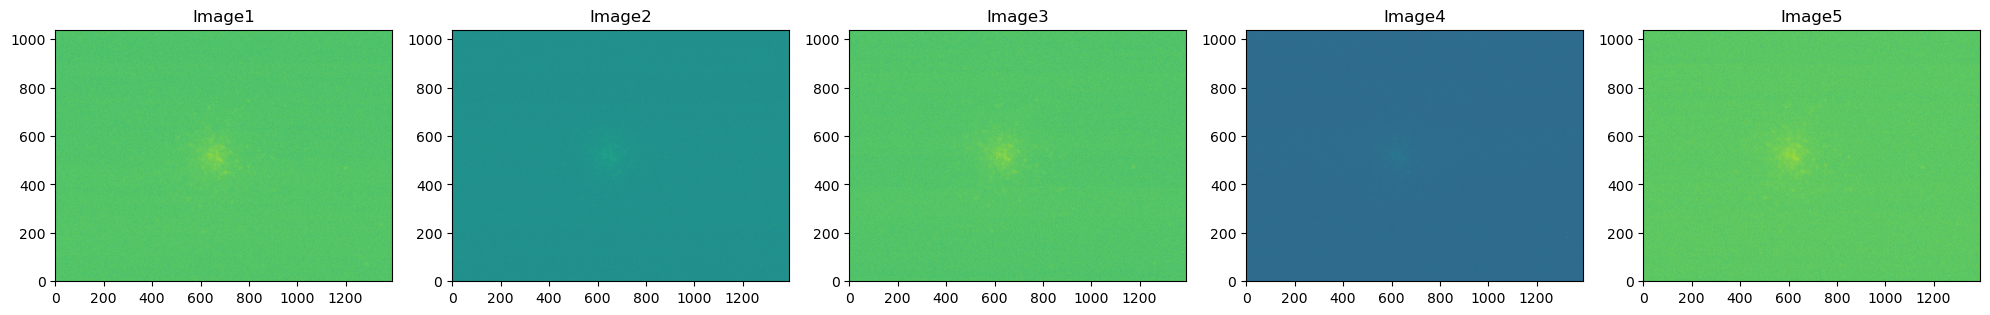

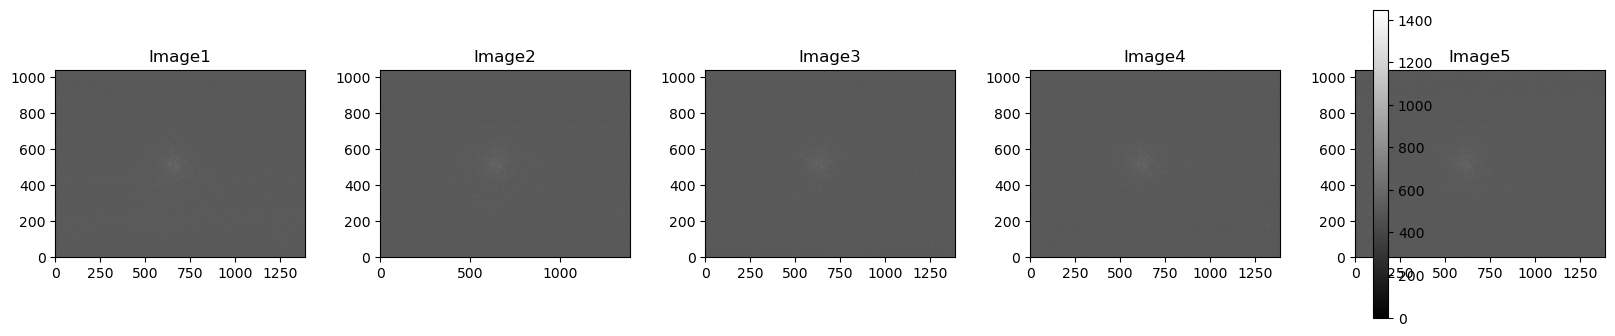

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20,4))
for i, ax in enumerate(axes): 
    ax.imshow(fits_data[i], origin="lower") 
    ax.set_title(f"Image{i+1}")
plt.tight_layout()
plt.show()

vmin = min(np.min(d) for d in fits_data) 
vmax = max(np.max(d) for d in fits_data) 

fig, axes = plt.subplots(1, 5, figsize=(20,4))
for i, ax in enumerate(axes): 
    im = ax.imshow(fits_data[i], origin = "lower", cmap="grey", vmin=vmin, vmax=vmax) 
    ax.set_title(f"Image{i+1}")
fig.colorbar(im, ax=axes.tolist())
plt.subplots_adjust(wspace=0.3)
plt.show()

In [8]:
#the dots in the middle are the same in the images but a bit easier to make out in the same color image than the other images! 


Image 1 - Mean: 510.47, Median: 512.00
Image 2 - Mean: 509.75, Median: 511.00
Image 3 - Mean: 508.05, Median: 510.00
Image 4 - Mean: 507.91, Median: 509.00
Image 5 - Mean: 508.79, Median: 510.00


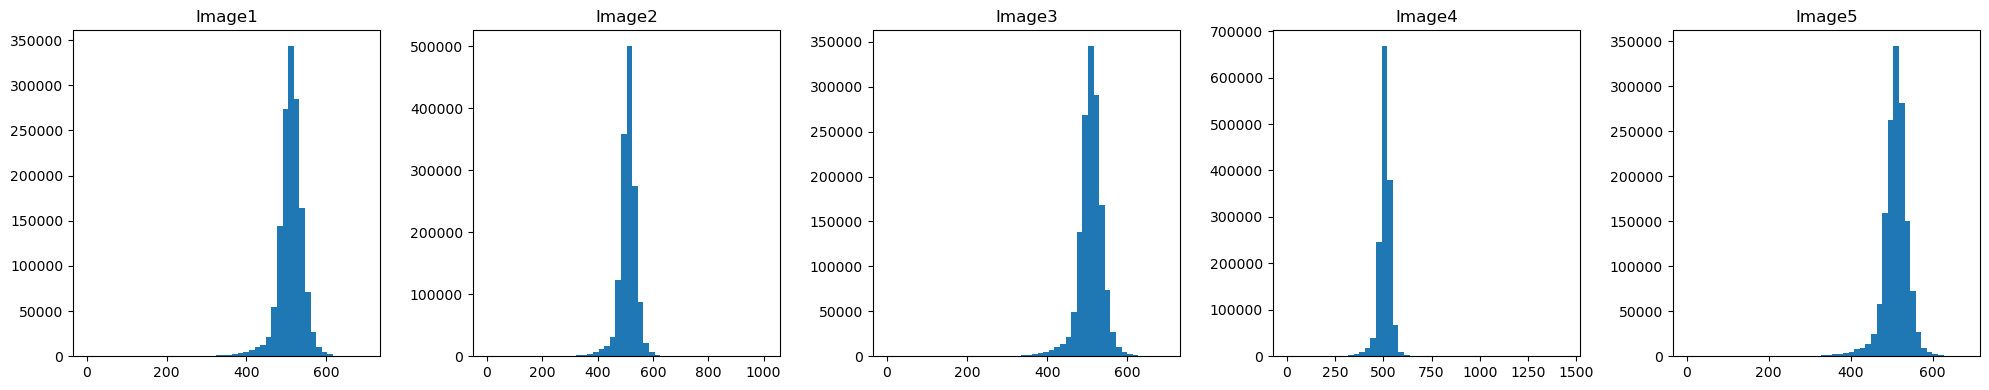

In [11]:
fig, axes = plt.subplots(1,5, figsize=(20,4))
for i, ax in enumerate(axes): 
    ax.hist(fits_data[i].ravel(), bins=50) 
    ax.set_title(f"Image{i+1}")
    print (f"Image {i+1} - Mean: {np.mean(fits_data[i]):.2f}, Median: {np.median(fits_data[i]):.2f}")
plt.tight_layout()
plt.show()

In [12]:
#a. x axis shows pixel intensity values (how bright each pixel is)
# and the y axis shows the count - how many pixels have that intensity
#B. the bins 50 means the range of pixel values is divided into 50 equal groups. 
#c. most of the data is around the low end of the intensity range while the image with its cluser
#d. most of the data is pretty packed into one region around the 400 pixel mark 
"""e.
Image 1 - Mean: 510.47, Median: 512.00
Image 2 - Mean: 509.75, Median: 511.00
Image 3 - Mean: 508.05, Median: 510.00
Image 4 - Mean: 507.91, Median: 509.00
Image 5 - Mean: 508.79, Median: 510."""



'e.\nImage 1 - Mean: 510.47, Median: 512.00\nImage 2 - Mean: 509.75, Median: 511.00\nImage 3 - Mean: 508.05, Median: 510.00\nImage 4 - Mean: 507.91, Median: 509.00\nImage 5 - Mean: 508.79, Median: 510.'

Combined median pixel value: 510.0


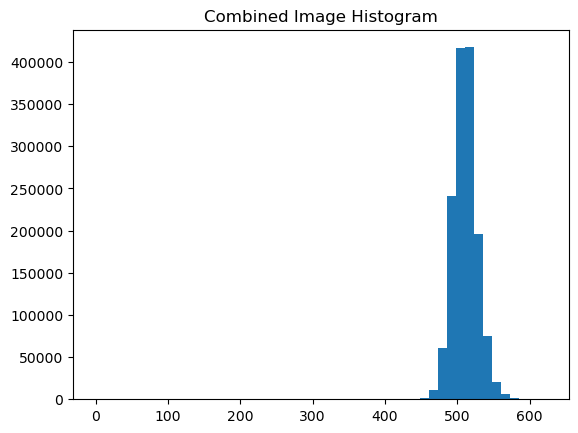

vmin=12.5, vmax = 610.5, diff=598.1


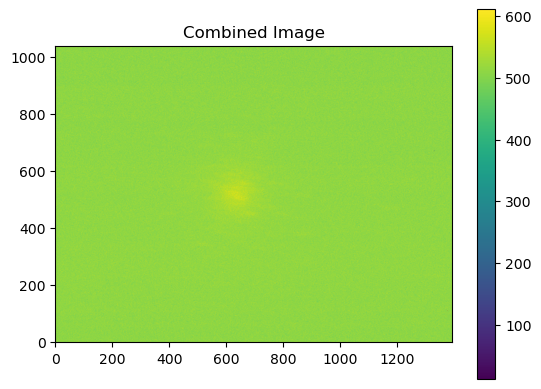

In [13]:
combined = np.median(fits_data, axis=0)
print("Combined median pixel value:", np.median(combined))

plt.figure()
counts, bin_edges, _ = plt.hist(combined.ravel(), bins=50)
plt.title("Combined Image Histogram")
plt.show() 

vmin = bin_edges[1]
vmax = bin_edges[-2]
print(f"vmin={vmin:.1f}, vmax = {vmax:.1f}, diff={vmax-vmin:.1f}")

plt.figure()
plt.imshow(combined, origin="lower", vmin=vmin, vmax=vmax) 
plt.colorbar()
plt.title("Combined Image")
plt.show() 

fits.writeto("combined.fits", combined, overwrite=True)